# Chapter 19. 실제 양자 하드웨어에서의 실행

## 소개

이 장에서는 양자 컴퓨팅을 실제 하드웨어에서 실행하는 방법을 다룬다. 시뮬레이터(Simulator)와 실제 양자 프로세서는 여러 차이점이 있다:

### 시뮬레이터 vs 실제 하드웨어

**시뮬레이터의 특징:**
- 완벽한 계산(Perfect Computation)
- 노이즈가 없음
- 빠른 실행
- 모든 큐비트 상태 정보 접근 가능

**실제 하드웨어의 특징:**
- 노이즈와 오류 존재(Noise and Errors)
- 제한된 연결성(Limited Connectivity)
- 디콜헤런스(Decoherence)
- 측정 오류(Measurement Error)
- 느린 실행 및 큐 대기(Queue and Waiting)

In [26]:
# 필수 라이브러리 임포트
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rcParams

# Qiskit 기본 라이브러리
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit.circuit import ParameterVector
from qiskit.circuit.library import ZZFeatureMap, RealAmplitudes
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit.transpiler import CouplingMap, Layout

# 시뮬레이터 및 프리미티브
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel, depolarizing_error, phase_damping_error, thermal_relaxation_error

# Qiskit Machine Learning (선택사항)
try:
    from qiskit_machine_learning.neural_networks import EstimatorQNN
    from qiskit_machine_learning.optimizers import COBYLA
    QML_AVAILABLE = True
except ImportError:
    QML_AVAILABLE = False

print("환경 설정 완료")
print(f"Qiskit Machine Learning 사용 가능: {QML_AVAILABLE}")

# 시각화 스타일 설정
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11

환경 설정 완료
Qiskit Machine Learning 사용 가능: True


## 시뮬레이터의 종류와 비교

### StatevectorSimulator vs AerSimulator

**StatevectorSimulator:**
- 상태 벡터(State Vector) 직접 시뮬레이션
- 완전한 양자 상태 정보 제공
- 노이즈 미지원
- 빠른 성능

**AerSimulator:**
- 다양한 시뮬레이션 방식 지원 (statevector, qasm, unitary)
- 노이즈 모델 지원
- 측정 샘플링 가능
- 실제 하드웨어에 더 가깝다

벨 상태 회로:


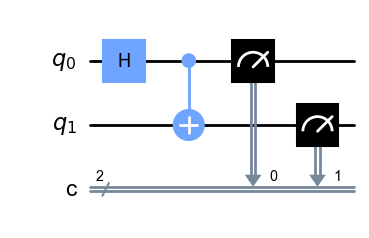

In [27]:
# 간단한 벨 상태 회로 생성
# Bell state |Φ+⟩ = (|00⟩ + |11⟩) / √2
qc_bell = QuantumCircuit(2, 2, name='Bell')
qc_bell.h(0)  # Hadamard 게이트 (중첩 상태 생성)
qc_bell.cx(0, 1)  # CNOT 게이트 (얽힘 생성)
qc_bell.measure([0, 1], [0, 1])  # 측정

# 회로 시각화
print("벨 상태 회로:")
qc_bell.draw(output='mpl', style='clifford')

In [28]:
# 이상적 시뮬레이터(노이즈 없음)로 실행
ideal_simulator = AerSimulator(method='statevector')

# 트랜스파일 없이 직접 실행
job_ideal = ideal_simulator.run(qc_bell, shots=1024)
result_ideal = job_ideal.result()
counts_ideal = result_ideal.get_counts()

print("이상적 시뮬레이터 결과:")
print(counts_ideal)

# 확률 계산
total_shots = sum(counts_ideal.values())
probs_ideal = {k: v/total_shots for k, v in counts_ideal.items()}
print(f"\n확률 분포:")
for state, prob in sorted(probs_ideal.items()):
    print(f"|{state}⟩: {prob:.4f}")

이상적 시뮬레이터 결과:
{'11': 493, '00': 531}

확률 분포:
|00⟩: 0.5186
|11⟩: 0.4814


In [29]:
# 노이즈 모델 정의
# 실제 하드웨어의 노이즈를 시뮬레이션한다

noise_model = NoiseModel()

# 1큐비트 게이트의 감극 노이즈(Depolarizing Noise)
# 확률 p로 단일 큐비트 오류가 발생한다
error_1q = depolarizing_error(0.01, 1)  # 1% 오류율

# 2큐비트 게이트의 감극 노이즈
error_2q = depolarizing_error(0.02, 2)  # 2% 오류율

# 측정 오류
error_measure = depolarizing_error(0.01, 1)

# 노이즈를 게이트에 추가한다
noise_model.add_all_qubit_quantum_error(error_1q, ['rz', 'sx', 'x'])
noise_model.add_all_qubit_quantum_error(error_2q, ['cx'])
noise_model.add_all_qubit_quantum_error(error_measure, 'measure')

print("노이즈 모델 정의 완료")
print(noise_model)

노이즈 모델 정의 완료
NoiseModel:
  Basis gates: ['cx', 'id', 'rz', 'sx', 'x']
  Instructions with noise: ['x', 'cx', 'measure', 'sx', 'rz']
  All-qubits errors: ['rz', 'sx', 'x', 'cx', 'measure']


In [30]:
# 노이즈 시뮬레이터로 실행
noisy_simulator = AerSimulator(noise_model=noise_model, method='automatic')

# 같은 벨 상태 회로를 노이즈 환경에서 실행
job_noisy = noisy_simulator.run(qc_bell, shots=1024)
result_noisy = job_noisy.result()
counts_noisy = result_noisy.get_counts()

print("노이즈 시뮬레이터 결과:")
print(counts_noisy)

# 확률 계산
probs_noisy = {k: v/total_shots for k, v in counts_noisy.items()}
print(f"\n노이즈 환경에서의 확률 분포:")
for state in ['00', '01', '10', '11']:
    prob = probs_noisy.get(state, 0)
    print(f"|{state}⟩: {prob:.4f}")

노이즈 시뮬레이터 결과:
{'01': 7, '10': 12, '00': 498, '11': 507}

노이즈 환경에서의 확률 분포:
|00⟩: 0.4863
|01⟩: 0.0068
|10⟩: 0.0117
|11⟩: 0.4951


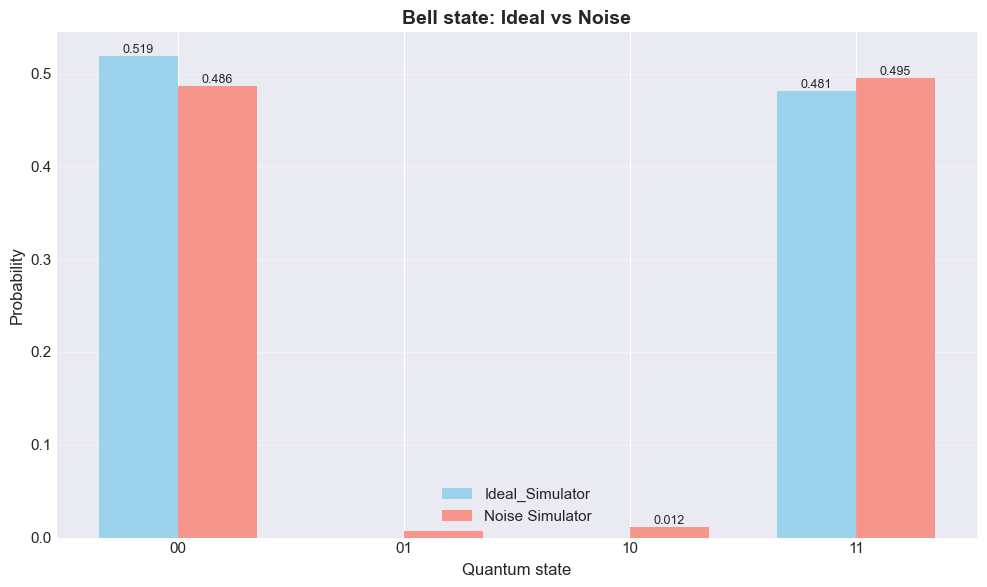

시뮬레이터 비교 그래프 생성 완료


In [31]:
# 이상적 환경 vs 노이즈 환경 비교 시각화
states = ['00', '01', '10', '11']
ideal_probs = [probs_ideal.get(s, 0) for s in states]
noisy_probs = [probs_noisy.get(s, 0) for s in states]

fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(states))
width = 0.35

bars1 = ax.bar(x - width/2, ideal_probs, width, label='Ideal_Simulator', alpha=0.8, color='skyblue')
bars2 = ax.bar(x + width/2, noisy_probs, width, label='Noise Simulator', alpha=0.8, color='salmon')

ax.set_xlabel('Quantum state', fontsize=12)
ax.set_ylabel('Probability', fontsize=12)
ax.set_title('Bell state: Ideal vs Noise', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(states)
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)

# 값 표시
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        if height > 0.01:
            ax.text(bar.get_x() + bar.get_width()/2., height,
                    f'{height:.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('/tmp/simulator_comparison.png', dpi=100, bbox_inches='tight')
plt.show()

print("시뮬레이터 비교 그래프 생성 완료")

## 노이즈 모델 이해

### 주요 노이즈 타입

**1. 감극 노이즈(Depolarizing Noise)**
- 확률 p로 단일 큐비트가 혼합 상태(Mixed State)로 변환
- 식: ρ → (1-p)ρ + (p/3)(σ_x ρ σ_x + σ_y ρ σ_y + σ_z ρ σ_z)
- 가장 일반적인 노이즈 모델

**2. 비트플립 노이즈(Bit-flip Error)**
- |0⟩ → |1⟩ 또는 |1⟩ → |0⟩로 전환
- σ_x 게이트 적용

**3. 위상 감쇠(Phase Damping)**
- 위상 정보 손실
- 간섭 현상 소실

**4. 열적 이완(Thermal Relaxation)**
- T1 (에너지 이완시간)
- T2 (위상 이완시간)
- 시간 경과에 따른 노이즈

In [32]:
# 다양한 노이즈 강도를 가진 노이즈 모델 생성
def create_noise_model(error_rate_1q, error_rate_2q, measurement_error_rate):
    """
    주어진 오류율로 노이즈 모델을 생성한다
    
    Args:
        error_rate_1q: 1큐비트 게이트 오류율
        error_rate_2q: 2큐비트 게이트 오류율
        measurement_error_rate: 측정 오류율
    
    Returns:
        NoiseModel 인스턴스
    """
    nm = NoiseModel()
    
    # 1큐비트 게이트 오류
    error_1q = depolarizing_error(error_rate_1q, 1)
    nm.add_all_qubit_quantum_error(error_1q, ['rz', 'sx', 'x', 'h'])
    
    # 2큐비트 게이트 오류
    error_2q = depolarizing_error(error_rate_2q, 2)
    nm.add_all_qubit_quantum_error(error_2q, ['cx'])
    
    # 측정 오류
    error_measure = depolarizing_error(measurement_error_rate, 1)
    nm.add_all_qubit_quantum_error(error_measure, 'measure')
    
    return nm

print("노이즈 모델 생성 함수 정의 완료")

노이즈 모델 생성 함수 정의 완료


In [33]:
# 노이즈 강도를 변화시키며 결과 비교
noise_levels = [0.0, 0.005, 0.01, 0.02, 0.05]
results_by_noise = {}

print("노이즈 강도별 시뮬레이션 실행 중...")
for noise_level in noise_levels:
    nm = create_noise_model(noise_level, noise_level*2, noise_level)
    sim = AerSimulator(noise_model=nm, method='automatic')
    job = sim.run(qc_bell, shots=1024)
    result = job.result()
    counts = result.get_counts()
    
    # 올바른 상태(00, 11) 확률 계산
    correct_prob = (counts.get('00', 0) + counts.get('11', 0)) / 1024
    results_by_noise[noise_level] = correct_prob
    print(f"노이즈율 {noise_level*100:.2f}%: 올바른 상태 확률 = {correct_prob:.4f}")

print("\n노이즈 강도별 시뮬레이션 완료")

노이즈 강도별 시뮬레이션 실행 중...
노이즈율 0.00%: 올바른 상태 확률 = 1.0000
노이즈율 0.50%: 올바른 상태 확률 = 0.9902
노이즈율 1.00%: 올바른 상태 확률 = 0.9736
노이즈율 2.00%: 올바른 상태 확률 = 0.9600
노이즈율 5.00%: 올바른 상태 확률 = 0.9053

노이즈 강도별 시뮬레이션 완료


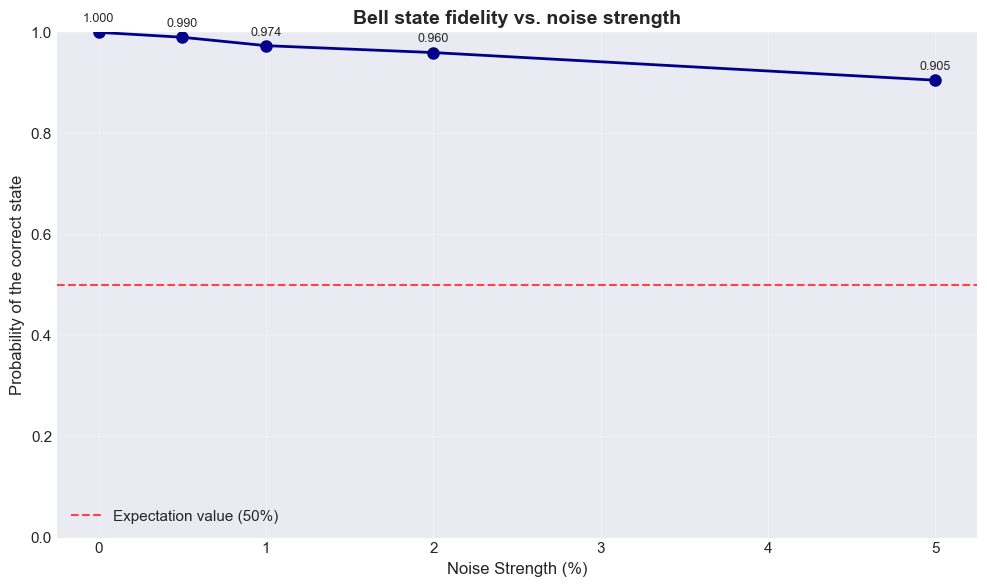

노이즈 영향 분석 그래프 생성 완료


In [34]:
# 노이즈 강도 vs 정확성 시각화
fig, ax = plt.subplots(figsize=(10, 6))

noise_percent = [n*100 for n in noise_levels]
correct_probs = [results_by_noise[n] for n in noise_levels]

ax.plot(noise_percent, correct_probs, 'o-', linewidth=2, markersize=8, color='darkblue')
ax.axhline(y=0.5, color='red', linestyle='--', linewidth=1.5, label='Expectation value (50%)', alpha=0.7)

ax.set_xlabel('Noise Strength (%)', fontsize=12)
ax.set_ylabel('Probability of the correct state', fontsize=12)
ax.set_title('Bell state fidelity vs. noise strength', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend(fontsize=11)
ax.set_ylim([0, 1])

# 값 표시
for x, y in zip(noise_percent, correct_probs):
    ax.text(x, y + 0.02, f'{y:.3f}', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('/tmp/noise_effect.png', dpi=100, bbox_inches='tight')
plt.show()

print("노이즈 영향 분석 그래프 생성 완료")

## 회로 트랜스파일링과 최적화

### 하드웨어 토폴로지(Topology)

실제 양자 프로세서는 모든 큐비트가 직접 연결되지 않는다:

- **Coupling Map**: 어떤 큐비트끼리 2큐비트 게이트를 실행할 수 있는지 정의
- 예) [[0,1], [1,2], [2,3]]: 0-1, 1-2, 2-3 연결만 가능
- 직접 연결되지 않은 큐비트 간 연산 → SWAP 게이트로 경로 재배치

### 기저 게이트셋(Basis Gates)

하드웨어가 지원하는 기본 게이트 집합:
- IBM: {u1, u2, u3, cx} 또는 {rz, sx, x, cx}
- 다른 게이트는 이 기본 게이트로 분해(Decompose)됨

### 최적화 레벨(Optimization Level)

- **Level 0**: 최소 트랜스파일 (빠름, 회로 길음)
- **Level 1**: 경량 최적화
- **Level 2**: 중간 최적화 (기본값)
- **Level 3**: 공격적 최적화 (느림, 회로 짧음)

In [35]:
# 가상 백엔드의 하드웨어 토폴로지 정의
# IBM Eagle 프로세서의 일부를 시뮬레이션한다

# Coupling map: (제어, 타겟) 큐비트 쌍
coupling_map = CouplingMap([
    [0, 1], [1, 0],  # 양방향
    [1, 2], [2, 1],
    [2, 3], [3, 2],
    [3, 4], [4, 3],
    [1, 5], [5, 1],
    [5, 6], [6, 5],
    [0, 5], [5, 0]
])

# 기저 게이트셋
basis_gates = ['rz', 'sx', 'x', 'cx']

print("하드웨어 토폴로지 설정 완료")
print(f"큐비트 수: {coupling_map.size()}")
print(f"기저 게이트: {basis_gates}")
print(f"\nCoupling Map:")
print(coupling_map)

하드웨어 토폴로지 설정 완료
큐비트 수: 7
기저 게이트: ['rz', 'sx', 'x', 'cx']

Coupling Map:
[[0, 1], [1, 0], [1, 2], [2, 1], [2, 3], [3, 2], [3, 4], [4, 3], [1, 5], [5, 1], [5, 6], [6, 5], [0, 5], [5, 0]]


원본 회로:
회로 깊이: 4
2큐비트 게이트 수: 4


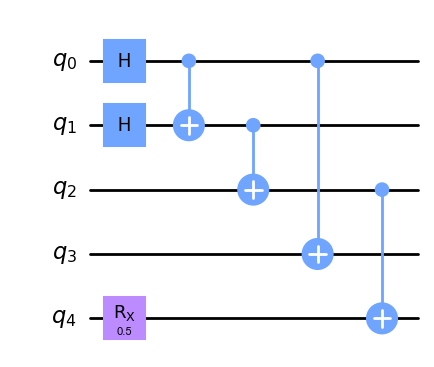

In [36]:
# 트랜스파일링 시연을 위한 복잡한 회로 생성
# 직접 연결되지 않은 큐비트 간 연산 포함
qc_complex = QuantumCircuit(5, name='Complex')

# 직접 연결된 큐비트 (0-1, 1-2 등)
qc_complex.h(0)
qc_complex.h(1)
qc_complex.cx(0, 1)  # 가능
qc_complex.cx(1, 2)  # 가능

# 직접 연결되지 않은 큐비트 (0과 3)
qc_complex.cx(0, 3)  # 불가능 → SWAP 필요

# 추가 게이트
qc_complex.rx(0.5, 4)
qc_complex.cx(2, 4)

print("원본 회로:")
print(f"회로 깊이: {qc_complex.depth()}")
print(f"2큐비트 게이트 수: {qc_complex.num_nonlocal_gates()}")
qc_complex.draw(output='mpl', style='clifford')

트랜스파일된 회로:
회로 깊이: 6
2큐비트 게이트 수: 4


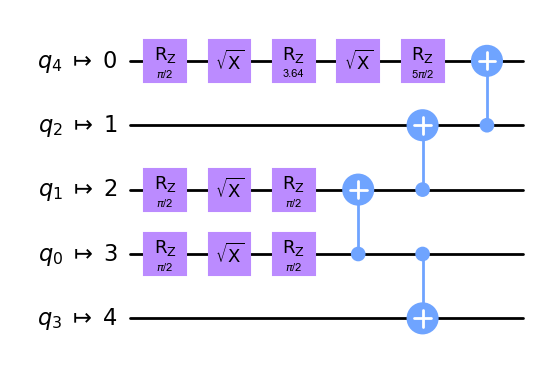

In [37]:
# 트랜스파일 후 회로 (예시)
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

pm = generate_preset_pass_manager(
    optimization_level=1,
    coupling_map=coupling_map,
    basis_gates=basis_gates
)
qc_optimized = pm.run(qc_complex)

print("트랜스파일된 회로:")
print(f"회로 깊이: {qc_optimized.depth()}")
print(f"2큐비트 게이트 수: {qc_optimized.num_nonlocal_gates()}")
qc_optimized.draw(output='mpl', style='clifford')

In [38]:
# 최적화 레벨별로 회로를 트랜스파일한다
optimization_levels = [0, 1, 2, 3]
transpiled_circuits = {}
metrics = {}

print("최적화 레벨별 트랜스파일 실행 중...\n")

for opt_level in optimization_levels:
    # Preset Pass Manager 생성
    pm = generate_preset_pass_manager(
        optimization_level=opt_level,
        coupling_map=coupling_map,
        basis_gates=basis_gates
    )
    
    # 트랜스파일 실행
    qc_transpiled = pm.run(qc_complex)
    transpiled_circuits[opt_level] = qc_transpiled
    
    # 메트릭 수집
    metrics[opt_level] = {
        'depth': qc_transpiled.depth(),
        'gates': qc_transpiled.size(),
        'cx_gates': qc_transpiled.num_nonlocal_gates()
    }
    
    print(f"최적화 레벨 {opt_level}:")
    print(f"  회로 깊이: {metrics[opt_level]['depth']}")
    print(f"  전체 게이트: {metrics[opt_level]['gates']}")
    print(f"  2큐비트 게이트: {metrics[opt_level]['cx_gates']}")
    print()

최적화 레벨별 트랜스파일 실행 중...

최적화 레벨 0:
  회로 깊이: 9
  전체 게이트: 21
  2큐비트 게이트: 10

최적화 레벨 1:
  회로 깊이: 6
  전체 게이트: 15
  2큐비트 게이트: 4

최적화 레벨 2:
  회로 깊이: 6
  전체 게이트: 15
  2큐비트 게이트: 4

최적화 레벨 3:
  회로 깊이: 6
  전체 게이트: 15
  2큐비트 게이트: 4



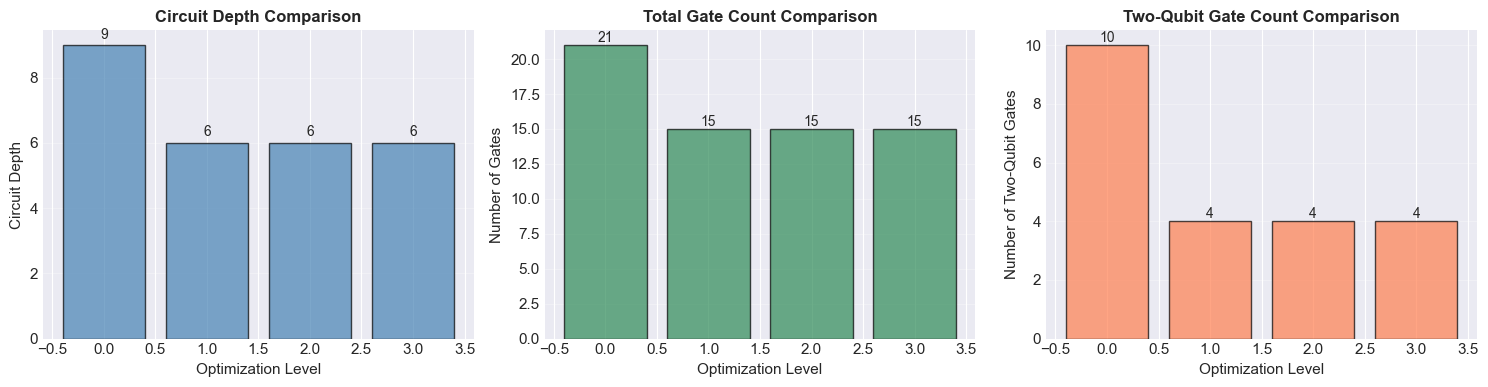

최적화 레벨 비교 그래프 생성 완료


In [39]:
# 최적화 레벨별 메트릭 시각화
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

levels = list(metrics.keys())
depths = [metrics[l]['depth'] for l in levels]
gates = [metrics[l]['gates'] for l in levels]
cx_gates = [metrics[l]['cx_gates'] for l in levels]

# 회로 깊이
axes[0].bar(levels, depths, color='steelblue', alpha=0.7, edgecolor='black')
axes[0].set_xlabel('Optimization Level', fontsize=11)
axes[0].set_ylabel('Circuit Depth', fontsize=11)
axes[0].set_title('Circuit Depth Comparison', fontsize=12, fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)
for i, (l, d) in enumerate(zip(levels, depths)):
    axes[0].text(l, d + 0.2, str(d), ha='center', fontsize=10)

# 전체 게이트 수
axes[1].bar(levels, gates, color='seagreen', alpha=0.7, edgecolor='black')
axes[1].set_xlabel('Optimization Level', fontsize=11)
axes[1].set_ylabel('Number of Gates', fontsize=11)
axes[1].set_title('Total Gate Count Comparison', fontsize=12, fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)
for i, (l, g) in enumerate(zip(levels, gates)):
    axes[1].text(l, g + 0.2, str(g), ha='center', fontsize=10)

# 2큐비트 게이트 수
axes[2].bar(levels, cx_gates, color='coral', alpha=0.7, edgecolor='black')
axes[2].set_xlabel('Optimization Level', fontsize=11)
axes[2].set_ylabel('Number of Two-Qubit Gates', fontsize=11)
axes[2].set_title('Two-Qubit Gate Count Comparison', fontsize=12, fontweight='bold')
axes[2].grid(axis='y', alpha=0.3)
for i, (l, c) in enumerate(zip(levels, cx_gates)):
    axes[2].text(l, c + 0.1, str(c), ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('/tmp/optimization_comparison.png', dpi=100, bbox_inches='tight')
plt.show()

print("최적화 레벨 비교 그래프 생성 완료")

## IBM Quantum 플랫폼 연동

### QiskitRuntimeService 설정

IBM Quantum 플랫폼에서 제공하는 실제 양자 프로세서에 접근하려면:

1. **API 토큰 획득**
   - IBM Quantum 웹사이트(https://quantum.ibm.com)에서 계정 생성
   - 계정 설정에서 API 토큰 복사

2. **QiskitRuntimeService 초기화**
   - 처음 한 번만 수행
   - 이후 자동으로 캐시에서 로드

3. **백엔드 선택**
   - least_busy(): 가장 대기 시간이 짧은 백엔드
   - 필터 옵션: min_num_qubits, simulator 등

4. **작업 제출**
   - EstimatorV2/SamplerV2로 실행
   - 작업은 큐에 들어가 대기
   - 결과 조회: session.run() 호출

### 비용 관리

- 무료: 시뮬레이터 (simulator=True)
- 유료: 실제 하드웨어 (하지만 평가판 크레딧 제공)
- 작업 우선순위: normal (무료), priority (유료)

In [40]:
# IBM Quantum 플랫폼 연동 예시
# 실제 실행하려면 API 토큰이 필요하다

# ============================================================
# 경고: 다음 코드는 실행하지 않는다 (API 토큰 필요)
# ============================================================

code_example = '''
from qiskit_ibm_runtime import QiskitRuntimeService, SamplerV2, EstimatorV2

# 1단계: 처음 한 번만 수행 (토큰 저장)
# QiskitRuntimeService.save_account(channel="ibm_quantum", token="YOUR_API_TOKEN")

# 2단계: 서비스 로드
service = QiskitRuntimeService(channel="ibm_quantum")

# 3단계: 백엔드 선택
# 시뮬레이터 사용 (무료)
backend = service.backend("ibmq_qasm_simulator")
print(f"선택된 백엔드: {backend.name}")
print(f"큐비트 수: {backend.num_qubits}")

# 실제 하드웨어 선택 (가장 대기 시간이 짧은 백엔드)
# backend = service.least_busy(simulator=False, min_num_qubits=5)

# 4단계: 트랜스파일
qc_transpiled = transpile(qc_complex, backend=backend)

# 5단계: 작업 제출
sampler = SamplerV2(backend=backend, options={"resilience_level": 1})
job = sampler.run([qc_transpiled])
print(f"작업 ID: {job.job_id()}")

# 6단계: 결과 조회 (작업 완료 때까지 대기)
result = job.result()
print(result)
'''

print("IBM Quantum 플랫폼 연동 코드 예시:")
print(code_example)

IBM Quantum 플랫폼 연동 코드 예시:

from qiskit_ibm_runtime import QiskitRuntimeService, SamplerV2, EstimatorV2

# 1단계: 처음 한 번만 수행 (토큰 저장)
# QiskitRuntimeService.save_account(channel="ibm_quantum", token="YOUR_API_TOKEN")

# 2단계: 서비스 로드
service = QiskitRuntimeService(channel="ibm_quantum")

# 3단계: 백엔드 선택
# 시뮬레이터 사용 (무료)
backend = service.backend("ibmq_qasm_simulator")
print(f"선택된 백엔드: {backend.name}")
print(f"큐비트 수: {backend.num_qubits}")

# 실제 하드웨어 선택 (가장 대기 시간이 짧은 백엔드)
# backend = service.least_busy(simulator=False, min_num_qubits=5)

# 4단계: 트랜스파일
qc_transpiled = transpile(qc_complex, backend=backend)

# 5단계: 작업 제출
sampler = SamplerV2(backend=backend, options={"resilience_level": 1})
job = sampler.run([qc_transpiled])
print(f"작업 ID: {job.job_id()}")

# 6단계: 결과 조회 (작업 완료 때까지 대기)
result = job.result()
print(result)



## 에러 완화(Error Mitigation) 기법

### 1. 측정 오류 완화(Measurement Error Mitigation)

측정 장치의 오류를 보정하는 방법:
- 보정 행렬(Calibration Matrix) 측정
- 고전 후처리(Classical Post-processing)로 결과 보정
- 측정값 반전 확률 학습

### 2. 영노이즈 외삽(Zero Noise Extrapolation, ZNE)

노이즈를 의도적으로 변화시키며 측정 후 외삽하는 방법:

1. 다양한 노이즈 강도에서 결과 측정
2. 노이즈 vs 기대값 그래프 작성
3. 영 노이즈 지점으로 외삽
4. 외삽된 값이 이상적 결과에 더 가까움

장점:
- 회로 구조 변경 불필요
- 모든 기대값에 적용 가능

단점:
- 여러 회로 실행 필요 (비용 증가)
- 외삽 방식에 따라 결과 편차

### 3. Resilience Level

IBM Quantum에서 제공하는 에러 완화 자동화:
- 레벨 0: 완화 없음
- 레벨 1: 측정 오류 완화
- 레벨 2: ZNE 포함
- 레벨 3: 더 강력한 완화 (실험적)

In [41]:
# 측정 오류 완화 시연
# 측정 오류가 있는 시뮬레이터에서 보정 행렬 생성

def measure_calibration_matrix(num_qubits, noise_model):
    """
    측정 보정 행렬을 구한다
    모든 기저 상태를 준비하고 측정하여 오류 학습
    """
    # 2^n 개의 기저 상태에 대해 보정
    num_states = 2 ** num_qubits
    cal_matrix = np.zeros((num_states, num_states))
    
    simulator = AerSimulator(noise_model=noise_model, method='automatic')
    
    for i in range(num_states):
        # i번째 기저 상태 준비
        qc = QuantumCircuit(num_qubits, num_qubits)
        
        # 이진 표현으로 상태 준비
        for j in range(num_qubits):
            if (i >> j) & 1:
                qc.x(j)
        
        qc.measure(list(range(num_qubits)), list(range(num_qubits)))
        
        # 측정 실행
        job = simulator.run(qc, shots=1024)
        counts = job.result().get_counts()
        
        # 측정 결과를 행렬에 저장
        for state, count in counts.items():
            j = int(state, 2)
            cal_matrix[j, i] = count / 1024
    
    return cal_matrix

# 2큐비트 노이즈 모델에서 보정 행렬 생성
nm_measure = create_noise_model(0.01, 0.02, 0.05)  # 5% 측정 오류
print("측정 보정 행렬 생성 중...")
cal_matrix = measure_calibration_matrix(2, nm_measure)
print(f"보정 행렬 (2x2 시뮬레이션):")
print(cal_matrix)
print(f"\n조건수 (Condition Number): {np.linalg.cond(cal_matrix):.2f}")

측정 보정 행렬 생성 중...
보정 행렬 (2x2 시뮬레이션):
[[0.95410156 0.01953125 0.0390625  0.00097656]
 [0.01660156 0.96191406 0.         0.03222656]
 [0.02929688 0.00097656 0.94628906 0.02734375]
 [0.         0.01757812 0.01464844 0.93945312]]

조건수 (Condition Number): 1.11


In [42]:
# 영노이즈 외삽(ZNE) 개념 시연
# 노이즈 강도를 변화시키며 기대값 측정 후 외삽

def apply_scaling_factor(qc, factor):
    """
    단일 큐비트 게이트를 반복하여 노이즈를 스케일링한다
    factor = 1: 원본
    factor > 1: 더 많은 노이즈
    """
    if factor < 1:
        return qc
    
    qc_scaled = QuantumCircuit(qc.num_qubits, qc.num_clbits)
    
    # 원본 회로 추가
    qc_scaled.compose(qc, inplace=True)
    
    # 단일 큐비트 게이트 다시 반복 (identity를 하되 노이즈 추가)
    # SQ(t) SQ†(t) 형태로 회로 길이 증가
    num_extra = int(factor * qc.num_qubits)
    for _ in range(num_extra):
        for i in range(qc.num_qubits):
            qc_scaled.rz(0, i)  # identity (하지만 노이즈 추가)
    
    return qc_scaled

print("ZNE를 위한 헬퍼 함수 정의 완료")

ZNE를 위한 헬퍼 함수 정의 완료


In [43]:
# ZNE 실행: 여러 스케일 팩터에서 기대값 측정
scale_factors = [1.0, 1.5, 2.0]
noisy_expectation_values = []

# 측정할 회로: 간단한 상태 준비 + 측정
qc_measure = QuantumCircuit(2, 2)
qc_measure.h(0)
qc_measure.h(1)
qc_measure.measure([0, 1], [0, 1])

nm_zne = create_noise_model(0.01, 0.02, 0.01)
sim_zne = AerSimulator(noise_model=nm_zne, method='automatic')

print("스케일 팩터별 ZNE 측정:")
for scale in scale_factors:
    # 회로 스케일링
    qc_scaled = apply_scaling_factor(qc_measure, scale)
    
    # 실행
    job = sim_zne.run(qc_scaled, shots=1024)
    counts = job.result().get_counts()
    
    # 기대값 계산 (|00⟩ + |11⟩의 확률)
    expected = (counts.get('00', 0) + counts.get('11', 0)) / 1024
    noisy_expectation_values.append(expected)
    
    print(f"스케일 팩터 {scale:.1f}: 기대값 = {expected:.4f}")

# 이상적 값 (노이즈 없을 때)
sim_ideal = AerSimulator(method='statevector')
job_ideal = sim_ideal.run(qc_measure, shots=1024)
counts_ideal = job_ideal.result().get_counts()
ideal_value = (counts_ideal.get('00', 0) + counts_ideal.get('11', 0)) / 1024
print(f"\n이상적 기대값 (노이즈 없음): {ideal_value:.4f}")

스케일 팩터별 ZNE 측정:
스케일 팩터 1.0: 기대값 = 0.4805
스케일 팩터 1.5: 기대값 = 0.5000
스케일 팩터 2.0: 기대값 = 0.4736

이상적 기대값 (노이즈 없음): 0.4863



ZNE 결과:
이상적 값: 0.4863
노이즈 환경 (스케일 1.0): 0.4805
ZNE 외삽 값: 0.3037
오류 감소: 0.0059 → 0.1826


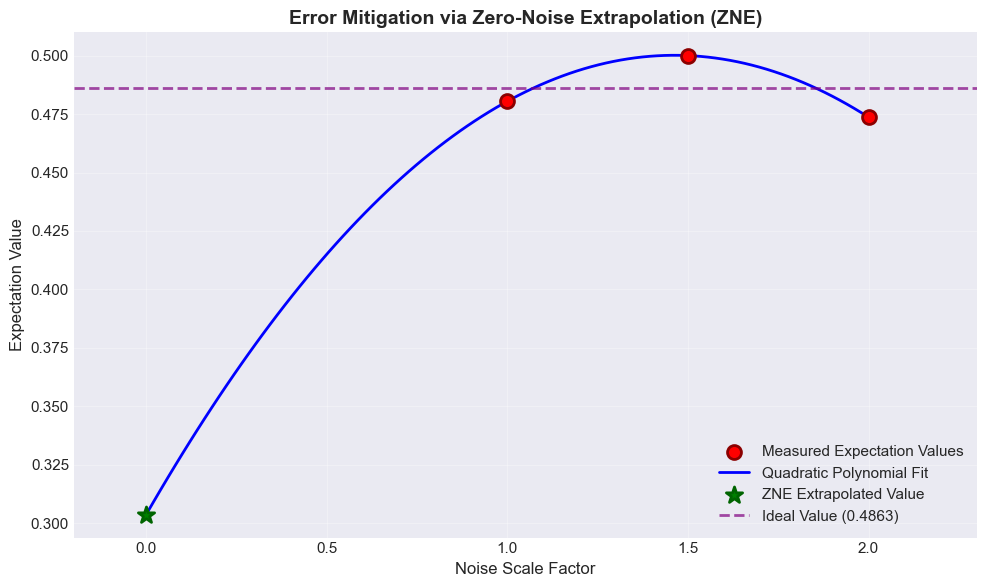


ZNE 외삽 그래프 생성 완료


In [44]:
# ZNE 외삽: 다항식 피팅으로 영 노이즈 값 추정
from numpy.polynomial import polynomial as P

# 2차 다항식으로 피팅
coeffs = P.polyfit(scale_factors, noisy_expectation_values, 2)

# 외삽된 값 (스케일 = 0)
zero_noise_estimate = P.polyval(0, coeffs)

print(f"\nZNE 결과:")
print(f"이상적 값: {ideal_value:.4f}")
print(f"노이즈 환경 (스케일 1.0): {noisy_expectation_values[0]:.4f}")
print(f"ZNE 외삽 값: {zero_noise_estimate:.4f}")
print(f"오류 감소: {abs(noisy_expectation_values[0] - ideal_value):.4f} → {abs(zero_noise_estimate - ideal_value):.4f}")

# 시각화
fig, ax = plt.subplots(figsize=(10, 6))

# 측정 데이터
ax.scatter(scale_factors, noisy_expectation_values, s=100, color='red',
           label='Measured Expectation Values', zorder=3, edgecolors='darkred', linewidth=2)

# 피팅 곡선
x_smooth = np.linspace(0, max(scale_factors), 100)
y_smooth = P.polyval(x_smooth, coeffs)
ax.plot(x_smooth, y_smooth, 'b-', linewidth=2, label='Quadratic Polynomial Fit')

# 외삽점
ax.scatter([0], [zero_noise_estimate], s=150, color='green',
           label='ZNE Extrapolated Value', marker='*', zorder=4, edgecolors='darkgreen', linewidth=2)

# 이상적 값
ax.axhline(y=ideal_value, color='purple', linestyle='--', linewidth=2,
           label=f'Ideal Value ({ideal_value:.4f})', alpha=0.7)

ax.set_xlabel('Noise Scale Factor', fontsize=12)
ax.set_ylabel('Expectation Value', fontsize=12)
ax.set_title('Error Mitigation via Zero-Noise Extrapolation (ZNE)', fontsize=14, fontweight='bold')
ax.legend(fontsize=11, loc='best')
ax.grid(True, alpha=0.3)
ax.set_xlim(-0.2, max(scale_factors) + 0.3)

plt.tight_layout()
plt.savefig('/tmp/zne_extrapolation.png', dpi=100, bbox_inches='tight')
plt.show()

print("\nZNE 외삽 그래프 생성 완료")

## 양자 머신러닝의 하드웨어 실행

### EstimatorV2와 SamplerV2

**EstimatorV2:**
- 관찰가능량(Observable)의 기대값 계산
- QNN 훈련에 사용
- 결과: 실수 기대값

**SamplerV2:**
- 회로의 측정 결과 샘플링
- 확률 분포 추출
- 결과: 측정 카운트

### 에러 억제(Error Suppression)

런타임 서비스의 resilience_level 옵션:
- **레벨 0**: 오류 억제 없음
- **레벨 1**: 측정 오류 완화
- **레벨 2**: ZNE + 측정 오류 완화
- **레벨 3**: 동적 디커플링(Dynamic Decoupling) 포함

### 매개변수화된 회로(Parameterized Circuit)

- 회로의 각도를 변수로 정의
- 최적화 알고리즘이 각도 조정
- 효율적인 훈련 가능

QNN 회로:
파라미터: ['theta[0]', 'theta[1]', 'theta[2]', 'theta[3]']


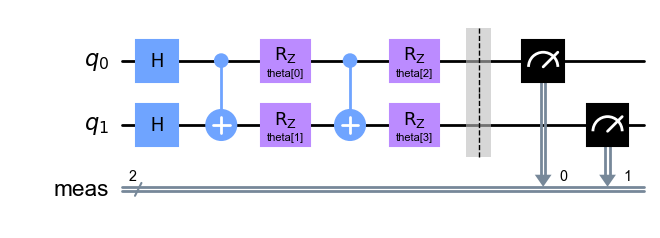

In [45]:
# 간단한 양자 신경망 회로
from qiskit.circuit import Parameter

# 파라미터 정의
theta = ParameterVector('theta', 4)

# QNN 회로 구성: Feature Map + Ansatz
qnn_circuit = QuantumCircuit(2, name='QNN')

# 입력 피처 맵
qnn_circuit.h(0)
qnn_circuit.h(1)
qnn_circuit.cx(0, 1)

# 파라미터화된 Ansatz
qnn_circuit.rz(theta[0], 0)
qnn_circuit.rz(theta[1], 1)
qnn_circuit.cx(0, 1)
qnn_circuit.rz(theta[2], 0)
qnn_circuit.rz(theta[3], 1)

# 측정
qnn_circuit.measure_all()

print("QNN 회로:")
print(f"파라미터: {[str(p) for p in theta]}")
qnn_circuit.draw(output='mpl', style='clifford')

In [46]:
from qiskit.quantum_info import Statevector, SparsePauliOp

# 관측 가능량
observable = SparsePauliOp.from_list([("ZZ", 1.0)])

param_values = np.linspace(0, 2*np.pi, 20)
ideal_expectations = []
noisy_expectations = []

nm_qnn = create_noise_model(0.01, 0.02, 0.01)
sim_noisy_qnn = AerSimulator(noise_model=nm_qnn, method='automatic')
shots = 1024

def zz_expectation(counts, shots):
    p00 = counts.get('00', 0) / shots
    p01 = counts.get('01', 0) / shots
    p10 = counts.get('10', 0) / shots
    p11 = counts.get('11', 0) / shots
    return p00 + p11 - p01 - p10

print("파라미터에 따른 기대값 계산 중...")

for param_val in param_values:
    param_dict = {theta[i]: param_val for i in range(4)}
    qc_bound = qnn_circuit.assign_parameters(param_dict)
    
    # 이상적 기댓값: Statevector로 해석적 계산 (측정 제거)
    qc_no_measure = qc_bound.remove_final_measurements(inplace=False)
    state = Statevector(qc_no_measure)
    exp_ideal = state.expectation_value(observable).real
    ideal_expectations.append(exp_ideal)
    
    # 노이즈 기댓값: 샷 기반 측정
    job_noisy = sim_noisy_qnn.run(qc_bound, shots=shots, seed_simulator=42)
    counts_noisy = job_noisy.result().get_counts()
    noisy_expectations.append(zz_expectation(counts_noisy, shots))

print(f"계산 완료: {len(ideal_expectations)}개 파라미터 값")

파라미터에 따른 기대값 계산 중...
계산 완료: 20개 파라미터 값


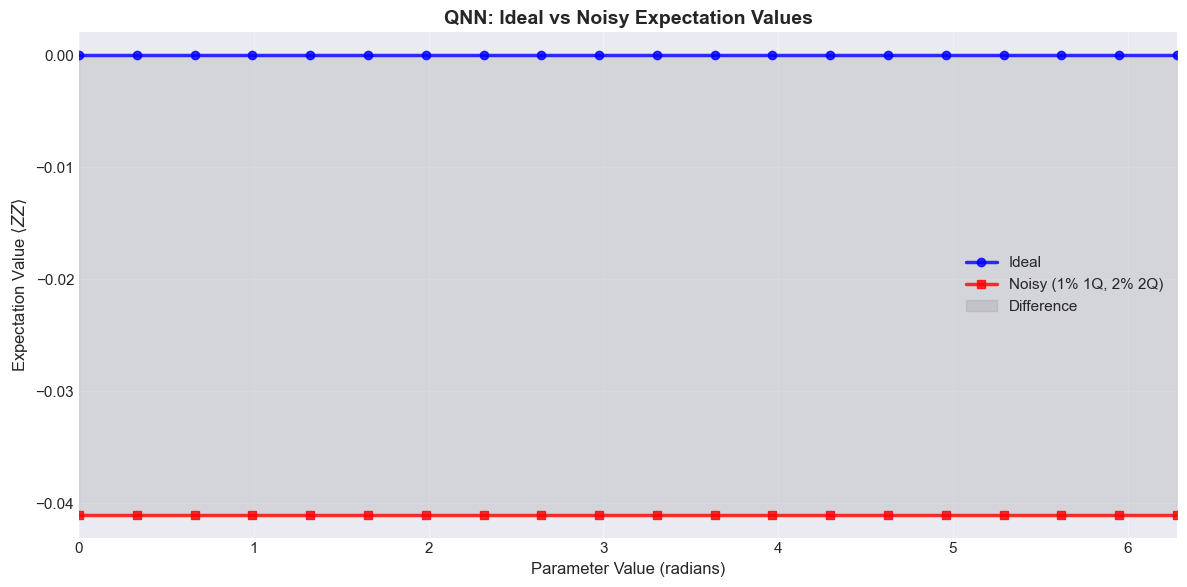


기대값 오류 분석:
평균 오류: 0.0410
최대 오류: 0.0410


In [47]:
# 이상적 환경 vs 노이즈 환경에서의 기대값 곡선
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(param_values, ideal_expectations, 'o-', linewidth=2.5, markersize=6,
        color='blue', label='Ideal', alpha=0.8)
ax.plot(param_values, noisy_expectations, 's-', linewidth=2.5, markersize=6,
        color='red', label='Noisy (1% 1Q, 2% 2Q)', alpha=0.8)
ax.fill_between(param_values, ideal_expectations, noisy_expectations,
                alpha=0.2, color='gray', label='Difference')

ax.set_xlabel('Parameter Value (radians)', fontsize=12)
ax.set_ylabel(r'Expectation Value $\langle ZZ \rangle$', fontsize=12)
ax.set_title('QNN: Ideal vs Noisy Expectation Values', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
ax.set_xlim(0, 2*np.pi)

plt.tight_layout()
plt.savefig('/tmp/qnn_learning_curve.png', dpi=100, bbox_inches='tight')
plt.show()

# 오류 분석
error_diff = np.array(noisy_expectations) - np.array(ideal_expectations)
mean_error = np.mean(np.abs(error_diff))
max_error = np.max(np.abs(error_diff))
print(f"\n기대값 오류 분석:")
print(f"평균 오류: {mean_error:.4f}")
print(f"최대 오류: {max_error:.4f}")

In [1]:
# 버전 정보 및 저작권을 표시한다(Display version information and copyright)
import tutorial_magics

%qiskit_version_table
%qiskit_copyright